# APPAC — correcting FID peak areas for atmospheric pressure

This notebook walks through the **APPAC** correction pipeline end-to-end on
`data/PLOT_FID.parquet`, identical to APPAC's dataset (six FID control cylinders,
five hydrocarbons, ~15 000 injections over ~5 years), and shows the diagnostic
plots that tell you whether the correction worked.

**The problem.** Gas-chromatograph peak areas drift with ambient pressure,
instrument bias, and slow detector ageing. For traceable results these artifacts
must be removed and the residual uncertainty quantified (GUM).

**The model.** APPAC fits a multiplicative correction
`corrected = raw / multiplier`, where the multiplier combines

* a single **common** pressure sensitivity `κ` (a detector property — an FID is
  carbon-equimolar, so `κ` is not component-specific),
* a per-episode **bias** (reset at instrument events / cylinder swaps),
* a cross-instrument **daily factor** and slow **drift** (PCA / PPCA).

Everything below is pure **NumPy/SciPy** (no JAX). See the `README` for the full
method and the GPL-3 license.

## 0. Imports

Requires `numpy`, `scipy`, `pandas`, `pyarrow`, `matplotlib`, and the `shrubbery`
package (run this notebook from the repository root so `import shrubbery` and the
relative data path resolve).


In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from shrubbery import (
    fit, fit_uncorrelated_drift, fit_generalized_correction,
    detect_breakpoints_global, apply_global_breakpoints,
    flag_outliers, build_multiplier, correct, propagate_covariance,
)
from shrubbery.load_rda import load_samples

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA    = "data/PLOT_FID.parquet"
EXCLUDE = ["CTL-4"]   # a degrading cylinder — kept out of the shared κ / drift


## 1. Load the data

`load_samples` reads the long-format Parquet file, pivots each cylinder to a
`(injections × peaks)` area matrix, attaches the `pressure` covariate, and
returns a reference pressure (the overall median). Cylinders may carry different
peak sets — `CTL-3` here has only four peaks.


In [2]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    samples, _, p_ref = load_samples(DATA)

all_peaks = sorted({p for s in samples for p in s.peaks})
print(f"{len(samples)} cylinders | peaks: {all_peaks} | pressure ref = {p_ref:.1f} hPa")
for s in samples:
    print(f"  {s.name:6s} n={len(s.dates):5d}  peaks={len(s.peaks)}  "
          f"days {int(s.dates.min())}-{int(s.dates.max())}  "
          f"P {s.covariates['pressure'].min():.0f}-{s.covariates['pressure'].max():.0f} hPa")


  Peaks: ['C2H6', 'C3H8', 'CH4', 'i-C4H10', 'n-C4H10']
  CTL-1                                     n= 5481  peaks=5  P=972.0–1042.1 hPa  dates=17885–19769
  CTL-2                                     n=  446  peaks=5  P=969.1–1033.9 hPa  dates=19430–19769
  CTL-3                                     n= 1033  peaks=4  P=972.8–1042.4 hPa  dates=17885–18334
  CTL-4                                     n= 3256  peaks=5  P=969.8–1041.9 hPa  dates=18034–19769
  CTL-5                                     n= 1299  peaks=5  P=968.4–1040.5 hPa  dates=17885–18542
  CTL-6                                     n= 3958  peaks=5  P=968.5–1041.5 hPa  dates=18201–19769

  Pressure reference: 1011.10 hPa (median of all observations)
6 cylinders | peaks: ['C2H6', 'C3H8', 'CH4', 'i-C4H10', 'n-C4H10'] | pressure ref = 1011.1 hPa
  CTL-1  n= 5481  peaks=5  days 17885-19769  P 972-1042 hPa
  CTL-2  n=  446  peaks=5  days 19430-19769  P 969-1034 hPa
  CTL-3  n= 1033  peaks=4  days 17885-18334  P 973-1042 hPa
  CTL-

## 2. Fit the correction model

The pipeline runs in three stages:

1. **Unbiased κ** — fit with *no* breakpoints. `κ` is estimated on
   *ep0-referenced* log-area deviations (each cylinder referenced to the
   geometric mean of its first episode), pooled over all peaks and cylinders.
   Because the reference is geometric and the regressor is the *measured*
   pressure, `κ` is unbiased by construction — no χ² centre-refinement needed.
2. **Breakpoint detection** — impute the cross-cylinder daily matrix (PPCA) and
   run change-point detection on the common drift score (PC2). Only
   *instrument-wide* events (cylinder swap, detector service) survive.
3. **Refit** with the detected breakpoints, holding `κ` fixed (it is a calibrated
   constant from stage 1), then add the slow-drift term.


In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # 1. unbiased common κ (no breakpoints)
    m0 = fit(samples, covariate_refs={"pressure": p_ref}, exclude=EXCLUDE)
    m0 = fit_uncorrelated_drift(samples, m0)
    kappa = m0.kappa

    # 2. instrument-wide breakpoints from the cross-sample PC2 drift score
    masks0 = flag_outliers(samples, m0)
    gen0   = fit_generalized_correction(samples, m0, outlier_masks=masks0,
                                        kappa_fixed=kappa)
    bpr         = detect_breakpoints_global(gen0)
    breakpoints = apply_global_breakpoints(samples, bpr)

    # 3. refit with breakpoints, κ fixed
    model = fit(samples, covariate_refs={"pressure": p_ref},
                breakpoints=breakpoints, exclude=EXCLUDE, kappa_fixed=kappa)
    model = fit_uncorrelated_drift(samples, model)
    masks = flag_outliers(samples, model)

print(f"common κ   = {kappa['pressure']:+.4e} hPa⁻¹")
print(f"  R²       = {m0.kappa_rsq['pressure']:.4f}    SE = {np.sqrt(m0.kappa_var['pressure']):.2e}")
print(f"breakpoints (days): {bpr.breakpoints.tolist()}")
print(f"dirty windows     : {bpr.dirty_windows}")


common κ   = -7.0637e-04 hPa⁻¹
  R²       = 0.9915    SE = 2.67e-06
breakpoints (days): [18001, 18318, 19408]
dirty windows     : [(18094, 18215), (18188, 18316), (18419, 18511), (19600, 19700)]


## 3. Diagnostic — the κ pressure fit

The estimator bins the pooled log-area deviations by pressure and runs a weighted
least-squares fit through the bin means (weight = bin count). A clean straight
line through the origin is what we want: the slope **is** `κ`. Curvature or scatter
here would mean pressure is not the whole story.


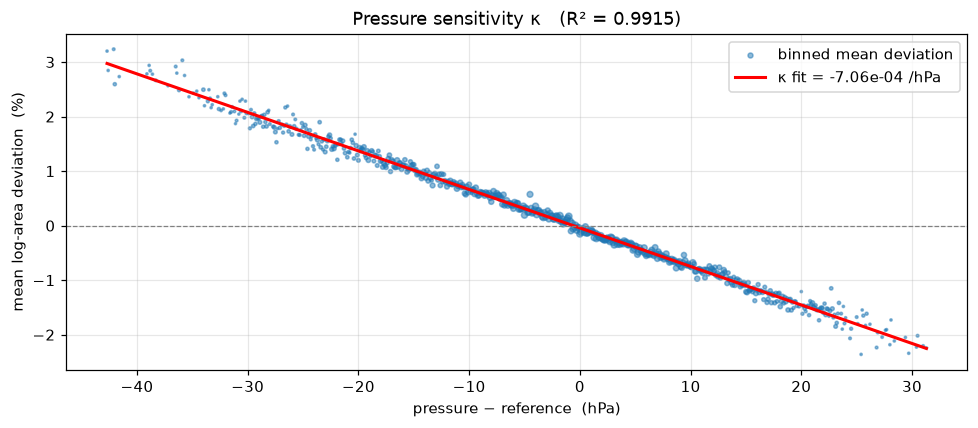

In [4]:
dp, w, y, yhat = m0.kappa_bins["pressure"]
fig, ax = plt.subplots()
ax.scatter(dp, y * 100, s=np.sqrt(w), alpha=0.5, label="binned mean deviation")
ax.plot(dp, yhat * 100, "r-", lw=2, label=f"κ fit = {kappa['pressure']:.2e} /hPa")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set(xlabel="pressure − reference  (hPa)",
       ylabel="mean log-area deviation  (%)",
       title=f"Pressure sensitivity κ   (R² = {m0.kappa_rsq['pressure']:.4f})")
ax.legend(); plt.tight_layout(); plt.show()


## 4. Before vs after — a single cylinder over time

For the cylinder with the most data we plot the **peak-mean** log-deviation
`mean_j log(area / centre)` per injection, raw vs corrected. The raw series
swings by a couple of percent (pressure + drift + bias); the corrected series
collapses onto zero. Dotted lines mark the detected breakpoints.


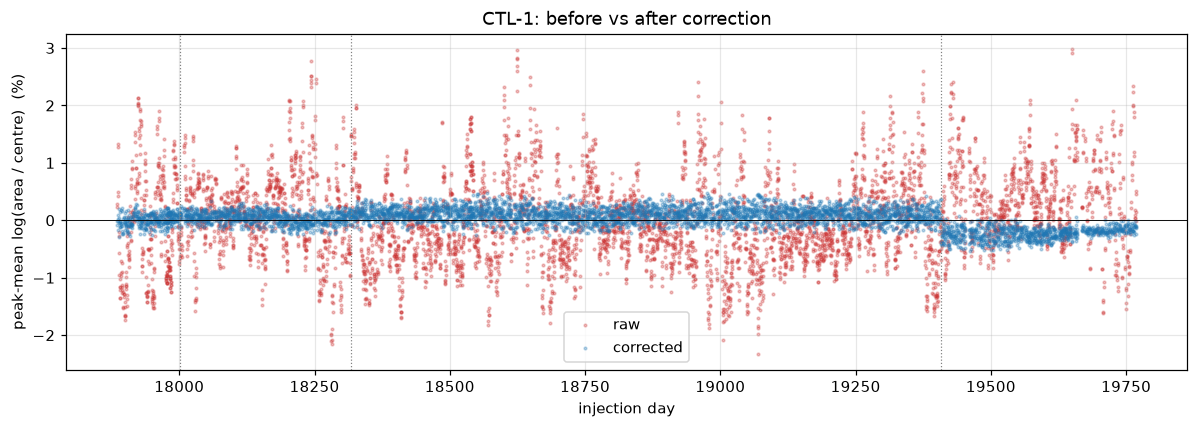

In [5]:
s    = max(samples, key=lambda s: len(s.dates))
Yc   = correct(s.Y, build_multiplier(s, model))
ct   = model.centers[s.name]
keep = ~masks[s.name]
day  = s.dates[keep]
raw_m = np.log(s.Y[keep] / ct).mean(1) * 100
cor_m = np.log(Yc[keep]  / ct).mean(1) * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(day, raw_m, s=3, alpha=0.3, color="#cc3333", label="raw")
ax.scatter(day, cor_m, s=3, alpha=0.3, color="#1f77b4", label="corrected")
for bp in bpr.breakpoints:
    ax.axvline(bp, color="grey", lw=0.8, ls=":")
ax.axhline(0, color="k", lw=0.6)
ax.set(xlabel="injection day", ylabel="peak-mean log(area / centre)  (%)",
       title=f"{s.name}: before vs after correction")
ax.legend(); plt.tight_layout(); plt.show()


## 5. Run-to-run scatter (RSD) per component

The headline metric: relative standard deviation of each peak's areas, before and
after correction, averaged over cylinders. APPAC typically takes ~0.8 % down to
~0.15–0.2 %.


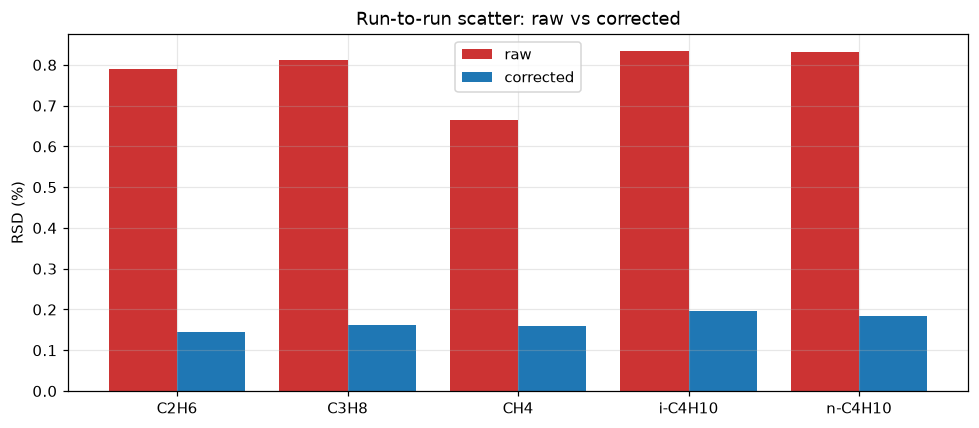

In [6]:
rsd_raw = {p: [] for p in all_peaks}
rsd_cor = {p: [] for p in all_peaks}
for s in samples:
    Yc = correct(s.Y, build_multiplier(s, model)); keep = ~masks[s.name]
    for j, p in enumerate(s.peaks):
        rsd_raw[p].append(s.Y[keep, j].std() / s.Y[keep, j].mean())
        rsd_cor[p].append(Yc[keep, j].std()  / Yc[keep, j].mean())

x   = np.arange(len(all_peaks))
raw = [np.mean(rsd_raw[p]) * 100 for p in all_peaks]
cor = [np.mean(rsd_cor[p]) * 100 for p in all_peaks]
fig, ax = plt.subplots()
ax.bar(x - 0.2, raw, 0.4, label="raw",       color="#cc3333")
ax.bar(x + 0.2, cor, 0.4, label="corrected", color="#1f77b4")
ax.set_xticks(x); ax.set_xticklabels(all_peaks)
ax.set(ylabel="RSD (%)", title="Run-to-run scatter: raw vs corrected")
ax.legend(); plt.tight_layout(); plt.show()


## 6. Are the residuals Gaussian?

If the correction removed the *structured* artifacts, what is left should be
close to white Gaussian noise. We pool the per-cylinder-centred corrected
residuals (6·MAD outliers removed) and check the histogram and a normal QQ plot.
A straight QQ line and near-zero excess kurtosis mean we are down to noise.


residual sd = 0.187%   excess kurtosis = +0.30   skew = -0.45


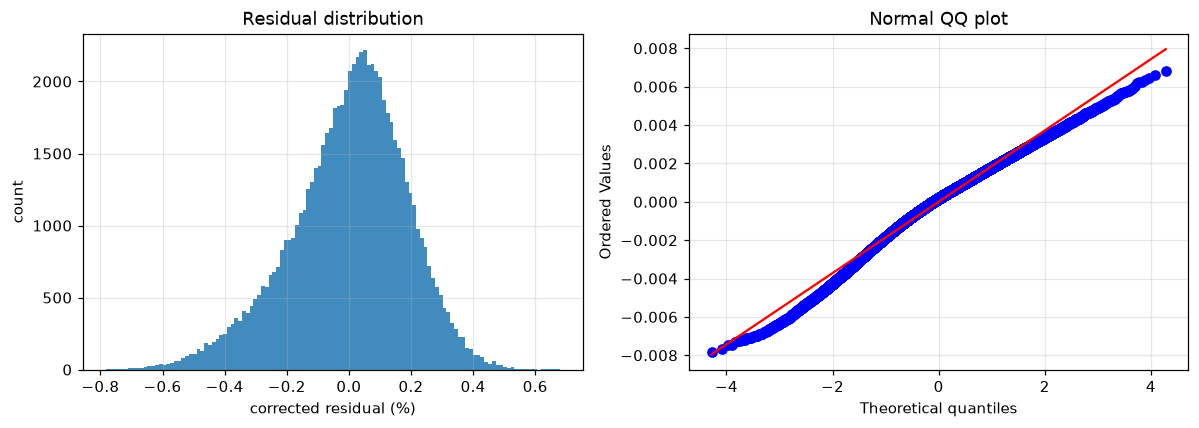

In [7]:
res = []
for s in samples:
    Yc = correct(s.Y, build_multiplier(s, model)); keep = ~masks[s.name]
    r  = np.log(Yc[keep] / model.centers[s.name]); r -= r.mean(0)
    res.append(r.ravel())
res = np.concatenate(res)
med = np.median(res); mad = np.median(np.abs(res - med)) * 1.4826
res = res[np.abs(res - med) <= 6 * mad]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(res * 100, bins=120, color="#1f77b4", alpha=0.85)
axes[0].set(xlabel="corrected residual (%)", ylabel="count",
            title="Residual distribution")
stats.probplot(res, dist="norm", plot=axes[1])
axes[1].set_title("Normal QQ plot")
plt.tight_layout(); plt.show()
print(f"residual sd = {res.std()*100:.3f}%   "
      f"excess kurtosis = {stats.kurtosis(res):+.2f}   skew = {stats.skew(res):+.2f}")


## 7. GUM combined uncertainty

APPAC propagates measurement + parameter uncertainty analytically (GUM Eq. 13;
no autodiff). Given a per-injection measurement covariance, `propagate_covariance`
returns the full covariance of the corrected areas. Here we assume a 0.1 %
per-injection input CV and report the median relative combined standard
uncertainty per peak.


In [8]:
s   = next(s for s in samples if s.name not in EXCLUDE)
idx = np.where(~masks[s.name])[0][:60]
Yk  = s.Y[idx]
cov_Y = (0.001 * Yk) ** 2                       # diagonal input variance, CV = 0.1 %
sub = type(s)(name=s.name, Y=Yk, dates=s.dates[idx],
              covariates={c: a[idx] for c, a in s.covariates.items()}, peaks=s.peaks)
Yc, cov = propagate_covariance(Yk, cov_Y, sub, model)
u = np.sqrt(np.clip(np.diag(cov), 0, None)).reshape(Yc.shape)

print(f"{s.name}: median relative combined uncertainty u_c (input CV 0.1%)")
for p, val in zip(s.peaks, np.median(u / Yc, 0) * 100):
    print(f"  {p:8s} {val:.3f} %")
eig = np.linalg.eigvalsh((cov + cov.T) / 2).min()
print(f"covariance positive semi-definite: {eig > -1e-9}  (min eig {eig:+.2e})")


CTL-1: median relative combined uncertainty u_c (input CV 0.1%)
  C2H6     0.113 %
  C3H8     0.117 %
  CH4      0.110 %
  i-C4H10  0.120 %
  n-C4H10  0.119 %
covariance positive semi-definite: True  (min eig +2.07e+00)


## Summary

* A single common `κ` plus episode bias and a cross-instrument drift model takes
  run-to-run scatter from ~0.8 % to ~0.15–0.2 % per component.
* The corrected residuals are close to Gaussian — the structured pressure/drift
  artifacts have been removed.
* Every corrected area carries a GUM uncertainty.

For the headless text version of this run, see `run_appac_on_data.py`; for the
full method and license, see the `README`.
